# Насколько мы переобучены на лидерборд

Данные: `reports/model_category_scores.csv` — одна строка на модель × разрез × категорию.
Только индивидуальные модели, стеки и бленды исключены.

**Покрытие неполное и это важно помнить при чтении:**

| | что есть |
|---|---|
| все 4 фолда + лидерборд | `mb_ce1_soup`, `mb_soup` |
| только fold_01 | `mb_ce1_fold01`, `mb_pretrain512`, `berta_*`, `mrb_bi_pretrain` |
| только лидерборд | `rubase_*`, `knrm_*`, `lgbm_*` |

Гиперпараметры, помеченные `?`, не сверялись с исходными командами.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

df = pd.read_csv('../reports/model_category_scores.csv')
df['prauc'] = pd.to_numeric(df['prauc'])
print(df.shape)
df.head()

(460, 16)


,model,base,format,trained_on,optimizer,lr,max_len,epochs,num_labels,init,aggregate,split,category,prauc,n_pairs,n_pos
0,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_02,Одежда,0.618612,5777.0,664.0
1,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_01,Ювелирные изделия,0.662248,4540.0,578.0
2,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_03,Обувь,0.628755,4616.0,436.0
3,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_03,Электроника,0.786366,4656.0,810.0
4,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_04,Канцелярские товары,0.817531,4403.0,1484.0


In [2]:
df

,model,base,format,trained_on,optimizer,lr,max_len,epochs,num_labels,init,aggregate,split,category,prauc,n_pairs,n_pos
0,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_02,Одежда,0.618612,5777.0,664.0
1,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_01,Ювелирные изделия,0.662248,4540.0,578.0
2,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_03,Обувь,0.628755,4616.0,436.0
3,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_03,Электроника,0.786366,4656.0,810.0
4,mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup,val_fold_04,Канцелярские товары,0.817531,4403.0,1484.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,lgbm_cheap,lightgbm,boosting,folds,-,?,-,?,-,-,none,leaderboard,Строительство и ремонт,0.358187,NaN,NaN
456,lgbm_cheap,lightgbm,boosting,folds,-,?,-,?,-,-,none,leaderboard,Товары для животных,0.306138,NaN,NaN
457,lgbm_cheap,lightgbm,boosting,folds,-,?,-,?,-,-,none,leaderboard,Хобби и творчество,0.198778,NaN,NaN
458,lgbm_cheap,lightgbm,boosting,folds,-,?,-,?,-,-,none,leaderboard,Электроника,0.415033,NaN,NaN


## Что вообще есть

Сначала карта покрытия — без неё любые выводы ниже будут о разных подмножествах моделей.

In [3]:
cover = (df.pivot_table(index='model', columns='split', values='prauc', aggfunc='count')
           .fillna(0).astype(int))
order = ['val_fold_01','val_fold_02','val_fold_03','val_fold_04','leaderboard']
cover[[c for c in order if c in cover.columns]]

split,val_fold_01,val_fold_02,val_fold_03,val_fold_04,leaderboard
model,,,,,
berta_bi_pre_folds,20,0,0,0,0
berta_ce_folds,20,0,0,0,0
berta_pretrain_e1,20,0,0,0,0
knrm_joint,0,0,0,0,20
knrm_llm_pretrain,0,0,0,0,20
lgbm_cheap,0,0,0,0,20
mb_ce1_fold01,20,0,0,0,20
mb_ce1_soup,20,20,20,20,20
mb_pretrain512,20,0,0,0,20


In [4]:
# паспорта моделей: по одной строке на модель
cols = ['model','base','format','trained_on','optimizer','lr','max_len',
        'epochs','num_labels','init','aggregate']
df[cols].drop_duplicates('model').set_index('model')

,base,format,trained_on,optimizer,lr,max_len,epochs,num_labels,init,aggregate
model,,,,,,,,,,
mb_ce1_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,soup
mb_soup,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,224,2,2,mb_llm,soup
mb_ce1_fold01,deepvk/RuModernBERT-base,cross-encoder,folds,adan,1e-4,512,1,1,mb_llm_512,none
mb_pretrain512,deepvk/RuModernBERT-base,cross-encoder,llm,adamw,3e-5?,512,1,1,-,none
berta_pretrain_e1,sergeyzh/BERTA,cross-encoder,llm,adamw,2e-5,512,1,1,-,none
mrb_bi_pretrain,deepvk/RuModernBERT-base,bi-encoder,llm,adamw,2e-5/1e-3,512,1,1,-,none
berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,1,1,berta_bi,none
berta_ce_folds,sergeyzh/BERTA,cross-encoder,folds,adan,2e-5,512,1,1,berta_ce,none
rubase_student384,DeepPavlov/rubert-base-cased,cross-encoder,folds,?,?,384,?,1,?,none


## Широкий вид: локально против лидерборда в одной строке

Исходный файл в длинном формате — одна строка на модель × разрез × категорию,
а различает их столбец `split`. Для сравнения удобнее широкий: `prauc_val` рядом с `prauc_lb`.

`prauc_val` усредняется по всем доступным фолдам модели. У большинства новых моделей
это только `fold_01`, поэтому рядом столбец `фолдов` — сколько их реально было.

In [5]:
val = (df[df.split.str.startswith('val_')]
         .groupby(['model','category'])['prauc']
         .agg(prauc_val='mean', фолдов='count').reset_index())
lb = (df[df.split == 'leaderboard'][['model','category','prauc']]
        .rename(columns={'prauc':'prauc_lb'}))

wide = val.merge(lb, on=['model','category'], how='outer')
wide = wide.merge(df[cols].drop_duplicates('model'), on='model', how='left')
wide['разница'] = wide['prauc_val'] - wide['prauc_lb']
wide['отношение'] = wide['prauc_val'] / wide['prauc_lb']

wide = wide[['model','base','format','trained_on','optimizer','lr','max_len',
             'category','prauc_val','фолдов','prauc_lb','разница','отношение']]
print('строк:', len(wide), '| с обоими разрезами:',
      int(wide[['prauc_val','prauc_lb']].notna().all(axis=1).sum()))
wide.round(4).head(20)

строк: 260 | с обоими разрезами: 80


,model,base,format,trained_on,optimizer,lr,max_len,category,prauc_val,фолдов,prauc_lb,разница,отношение
0,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Автотовары,0.6599,1.0,NaN,NaN,NaN
1,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Аптека,0.8509,1.0,NaN,NaN,NaN
2,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Бытовая техника,0.8068,1.0,NaN,NaN,NaN
3,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Бытовая химия,0.8731,1.0,NaN,NaN,NaN
4,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Галантерея и аксессуары,0.6237,1.0,NaN,NaN,NaN
5,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Детские товары,0.8687,1.0,NaN,NaN,NaN
6,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Дом и сад,0.7619,1.0,NaN,NaN,NaN
7,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Канцелярские товары,0.7348,1.0,NaN,NaN,NaN
8,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Красота и гигиена,0.8001,1.0,NaN,NaN,NaN
9,berta_bi_pre_folds,sergeyzh/BERTA,bi-encoder,folds,adamw,1e-5/2e-4,512,Мебель,0.6509,1.0,NaN,NaN,NaN


In [6]:
# только строки, где есть оба разреза — на них и строится весь анализ ниже
paired = wide.dropna(subset=['prauc_val','prauc_lb']).copy()
print('моделей:', paired.model.nunique(), '| категорий:', paired.category.nunique())
paired.pivot_table(index='category', columns='model',
                   values=['prauc_val','prauc_lb']).round(4)

моделей: 4 | категорий: 20


prauc_lb                                        prauc_val                                   
model                   mb_ce1_fold01 mb_ce1_soup mb_pretrain512 mb_soup mb_ce1_fold01 mb_ce1_soup mb_pretrain512 mb_soup
category                                                                                                                 
Автотовары                     0.8433      0.8483         0.8164  0.8511        0.7305      0.7370         0.6465  0.7365
Аптека                         0.6771      0.6870         0.6499  0.6629        0.8860      0.8888         0.7740  0.8868
Бытовая техника                0.5878      0.5962         0.5722  0.5885        0.8627      0.8598         0.7721  0.8603
Бытовая химия                  0.6858      0.6993         0.6858  0.7026        0.9177      0.9218         0.8493  0.9215
Галантерея и аксессуары        0.2374      0.2487         0.3480  0.2647        0.7586      0.7612         0.5264  0.7591
Детские товары                 0.5136      0.5366         0.5846  0.5446        0.9259      0.9269         0.8551  0.9269
Дом и сад                      0.4518      0.4653         0.4818  0.4502        0.8606      0.8619         0.7361  0.8602
Канцелярские товары            0.3995      0.4128         0.4203  0.4070        0.8218      0.8324         0.6883  0.8296
Красота и гигиена              0.5011      0.5090         0.6226  0.5061        0.8499      0.8477         0.7659  0.8456
Мебель                         0.4106      0.4420         0.3703  0.4020        0.7875      0.7959         0.6282  0.7861
Музыкальные инструменты        0.5574      0.5686         0.5398  0.5774        0.8811      0.8845         0.7880  0.8856
Обувь                          0.0943      0.0988         0.1821  0.0963        0.6186      0.6146         0.3331  0.6002
Одежда                         0.1394      0.1468         0.2145  0.1304        0.6392      0.6246         0.4249  0.6098
Продукты питания               0.7780      0.7890         0.6825  0.7931        0.8974      0.8994         0.8056  0.8982
Спорт и отдых                  0.4028      0.4140         0.4231  0.4256        0.7642      0.7563         0.6719  0.7562
Строительство и ремонт         0.6282      0.6387         0.5817  0.6219        0.8174      0.8345         0.7155  0.8274
Товары для животных            0.5892      0.6028         0.6274  0.6027        0.9145      0.9143         0.8463  0.9138
Хобби и творчество             0.5573      0.5764         0.6054  0.6015        0.9396      0.9442         0.8588  0.9433
Электроника                    0.6124      0.6142         0.4792  0.6185        0.8138      0.8029         0.7043  0.8014
Ювелирные изделия              0.3824      0.3763         0.3462  0.2735        0.6707      0.6375         0.4672  0.6283

## Макро по разрезам

`val_*` считается на нашей ручной разметке, где доля дублей 25.7%.
На тесте она 11.1%, и перекос свой в каждой категории — от 1.5 до 7.9 раза.
Поэтому абсолютные величины между разрезами несравнимы, а вот **порядок моделей** сравнивать можно.

In [7]:
macro = df.pivot_table(index='model', columns='split', values='prauc', aggfunc='mean')
macro = macro[[c for c in order if c in macro.columns]]
macro['val_mean'] = macro[[c for c in macro.columns if c.startswith('val_')]].mean(axis=1)
macro.sort_values('leaderboard', ascending=False).round(4)

split,val_fold_01,val_fold_02,val_fold_03,val_fold_04,leaderboard,val_mean
model,,,,,,
mb_ce1_soup,0.8159,0.8196,0.8162,0.8175,0.5135,0.8173
mb_pretrain512,0.6929,NaN,NaN,NaN,0.5117,0.6929
mb_soup,0.8119,0.8161,0.8128,0.8145,0.5060,0.8138
mb_ce1_fold01,0.8179,NaN,NaN,NaN,0.5025,0.8179
rubase_student384,NaN,NaN,NaN,NaN,0.4982,NaN
rubase192,NaN,NaN,NaN,NaN,0.4719,NaN
knrm_llm_pretrain,NaN,NaN,NaN,NaN,0.2633,NaN
lgbm_cheap,NaN,NaN,NaN,NaN,0.2573,NaN
knrm_joint,NaN,NaN,NaN,NaN,0.2369,NaN


## Главное: схлопывание разрывов

Если локальная валидация честно предсказывает лидерборд, то разница между двумя моделями
должна сохраняться. Проверяем на парах моделей, у которых есть оба разреза.

In [8]:
both = macro.dropna(subset=['leaderboard']).dropna(subset=['val_mean'])
rows = []
for a in both.index:
    for b in both.index:
        if a >= b:
            continue
        dv = both.loc[a,'val_mean'] - both.loc[b,'val_mean']
        dl = both.loc[a,'leaderboard'] - both.loc[b,'leaderboard']
        rows.append(dict(модель_A=a, модель_B=b, разрыв_val=round(dv,4),
                         разрыв_лб=round(dl,4),
                         во_сколько_раз=round(dv/dl,1) if abs(dl) > 1e-9 else np.nan,
                         знак_совпал=(dv > 0) == (dl > 0)))
pairs = pd.DataFrame(rows).sort_values('разрыв_val', key=abs, ascending=False)
pairs

,модель_A,модель_B,разрыв_val,разрыв_лб,во_сколько_раз,знак_совпал
1,mb_ce1_fold01,mb_pretrain512,0.1250,-0.0092,-13.6,False
3,mb_ce1_soup,mb_pretrain512,0.1244,0.0018,67.4,True
5,mb_pretrain512,mb_soup,-0.1210,0.0057,-21.4,False
2,mb_ce1_fold01,mb_soup,0.0041,-0.0036,-1.1,False
4,mb_ce1_soup,mb_soup,0.0035,0.0075,0.5,True
0,mb_ce1_fold01,mb_ce1_soup,0.0006,-0.0111,-0.1,False


In [9]:
print('пар всего:', len(pairs))
print('знак сохранился:', int(pairs['знак_совпал'].sum()), 'из', len(pairs))
print('медианное схлопывание разрыва: в', round(pairs['во_сколько_раз'].abs().median(),1), 'раз')

пар всего: 6
знак сохранился: 2 из 6
медианное схлопывание разрыва: в 7.4 раз


## Покатегорийно: предсказывает ли локальный порядок лидербордный

Считаем корреляцию рангов моделей внутри каждой категории.
Единица означала бы, что локально мы видим тот же порядок, что на тесте.

In [10]:
piv = df[df.model.isin(both.index)].pivot_table(
    index=['category','model'], columns='split', values='prauc', aggfunc='mean').reset_index()
piv['val'] = piv[[c for c in piv.columns if str(c).startswith('val_')]].mean(axis=1)
piv = piv.dropna(subset=['val','leaderboard'])

res = []
for cat, part in piv.groupby('category'):
    if len(part) < 3:
        continue
    rho = part['val'].rank().corr(part['leaderboard'].rank())
    res.append(dict(категория=cat, моделей=len(part), корреляция_рангов=round(rho,3),
                    val_макро=round(part['val'].mean(),4),
                    лб_макро=round(part['leaderboard'].mean(),4)))
bycat = pd.DataFrame(res).sort_values('корреляция_рангов')
bycat

,категория,моделей,корреляция_рангов,val_макро,лб_макро
8,Красота и гигиена,4,-0.8,0.8273,0.5347
16,Товары для животных,4,-0.8,0.8972,0.6055
11,Обувь,4,-0.8,0.5416,0.1179
14,Спорт и отдых,4,-0.8,0.7371,0.4164
17,Хобби и творчество,4,-0.4,0.9215,0.5852
4,Галантерея и аксессуары,4,-0.4,0.7013,0.2747
12,Одежда,4,-0.4,0.5746,0.1578
5,Детские товары,4,-0.2,0.9087,0.5449
6,Дом и сад,4,-0.2,0.8297,0.4623
7,Канцелярские товары,4,-0.2,0.7930,0.4099


## Сдвиг распределения как причина

Доля дублей в нашей разметке против доли в тесте. Тестовая получена зондом `probe_allones`:
при постоянном предсказании PR-AUC равен базовой доле.

In [11]:
prior = df[df.split.str.startswith('val_')].groupby('category')[['n_pairs','n_pos']].sum()
prior['доля_train'] = prior['n_pos'] / prior['n_pairs']
lb_base = {'Автотовары':0.1178,'Аптека':0.1273,'Бытовая техника':0.2099,'Бытовая химия':0.2119,
 'Галантерея и аксессуары':0.0430,'Детские товары':0.1468,'Дом и сад':0.0939,
 'Канцелярские товары':0.0949,'Красота и гигиена':0.2158,'Мебель':0.0490,
 'Музыкальные инструменты':0.1347,'Обувь':0.0458,'Одежда':0.0573,'Продукты питания':0.1146,
 'Спорт и отдых':0.1115,'Строительство и ремонт':0.1290,'Товары для животных':0.1451,
 'Хобби и творчество':0.0974,'Электроника':0.0647,'Ювелирные изделия':0.0157}
prior['доля_тест'] = prior.index.map(lb_base)
prior['во_сколько_раз'] = (prior['доля_train'] / prior['доля_тест']).round(1)
prior[['доля_train','доля_тест','во_сколько_раз']].sort_values('во_сколько_раз', ascending=False).round(4)

,доля_train,доля_тест,во_сколько_раз
category,,,
Ювелирные изделия,0.1254,0.0157,8.0
Хобби и творчество,0.4617,0.0974,4.7
Галантерея и аксессуары,0.1650,0.0430,3.8
Детские товары,0.5591,0.1468,3.8
Канцелярские товары,0.3371,0.0949,3.6
Мебель,0.1493,0.0490,3.0
Дом и сад,0.2588,0.0939,2.8
Электроника,0.1707,0.0647,2.6
Продукты питания,0.2744,0.1146,2.4


## Картинки

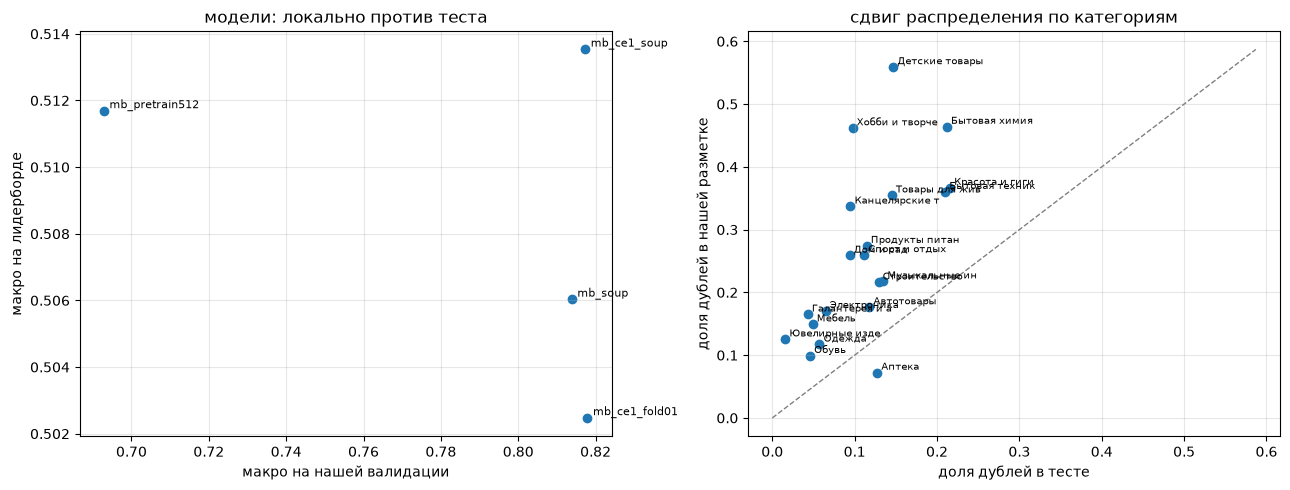

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

b = both.dropna(subset=['val_mean','leaderboard'])
ax[0].scatter(b['val_mean'], b['leaderboard'])
for name, row in b.iterrows():
    ax[0].annotate(name, (row['val_mean'], row['leaderboard']), fontsize=8,
                   xytext=(4, 2), textcoords='offset points')
ax[0].set_xlabel('макро на нашей валидации')
ax[0].set_ylabel('макро на лидерборде')
ax[0].set_title('модели: локально против теста')
ax[0].grid(alpha=.3)

p = prior.dropna(subset=['доля_тест'])
ax[1].scatter(p['доля_тест'], p['доля_train'])
lim = [0, max(p['доля_train'].max(), p['доля_тест'].max()) * 1.05]
ax[1].plot(lim, lim, '--', lw=1, color='gray')
for name, row in p.iterrows():
    ax[1].annotate(name[:14], (row['доля_тест'], row['доля_train']), fontsize=7,
                   xytext=(3, 2), textcoords='offset points')
ax[1].set_xlabel('доля дублей в тесте')
ax[1].set_ylabel('доля дублей в нашей разметке')
ax[1].set_title('сдвиг распределения по категориям')
ax[1].grid(alpha=.3)
plt.tight_layout()

## Что стоит проверить дальше

- Досчитать фолды 02–04 для шести новых моделей — сейчас по ним только первый фолд,
  и разброс между фолдами (у `mb_ce1_soup` он 0.8159…0.8196) не с чем сравнить.
- Пересчитать валидацию с прореженными позитивами под тестовую долю и посмотреть,
  сохранится ли порядок моделей. Заготовка выборки: `/tmp/val_testprior.parquet`.
- Локальных предсказаний по моделям Далера и KNRM/LightGBM нет вовсе, они входят
  в анализ только строкой лидерборда.

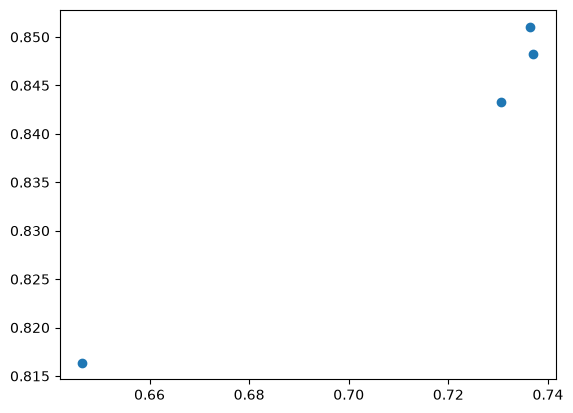

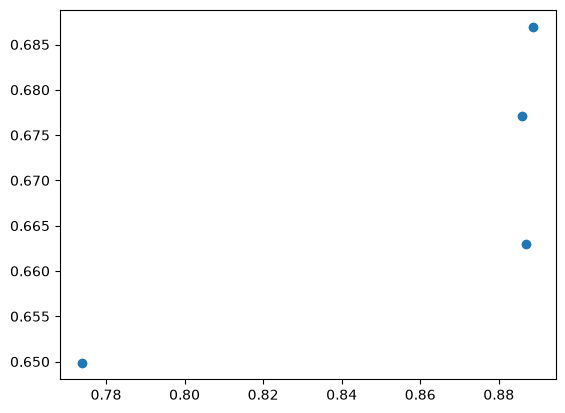

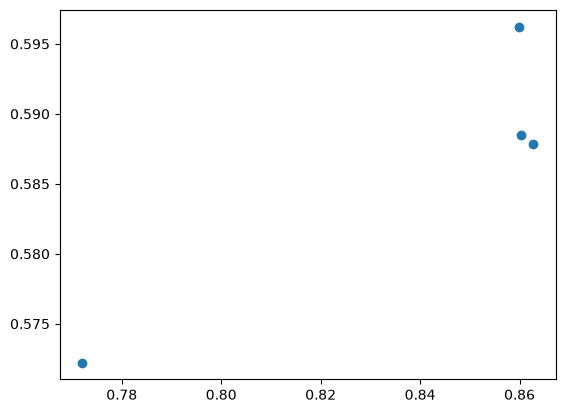

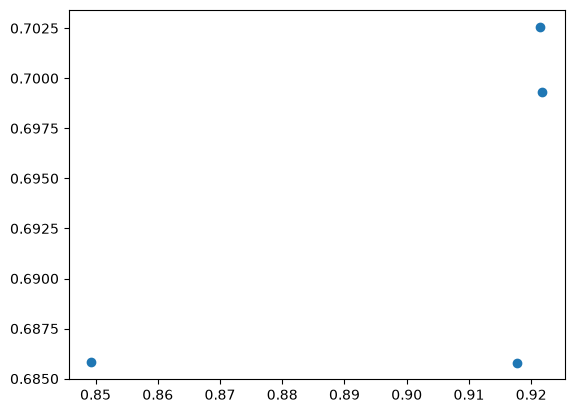

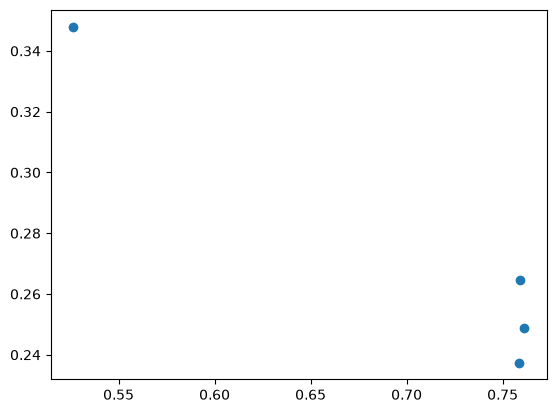

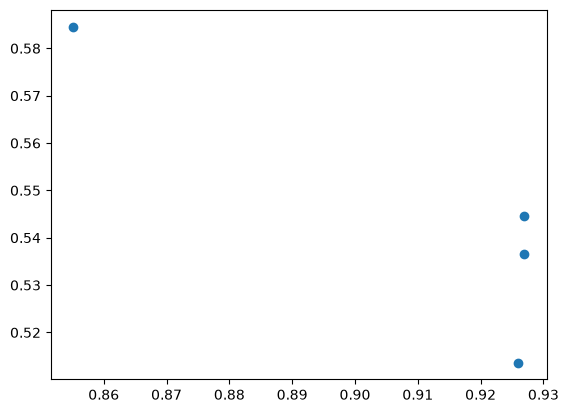

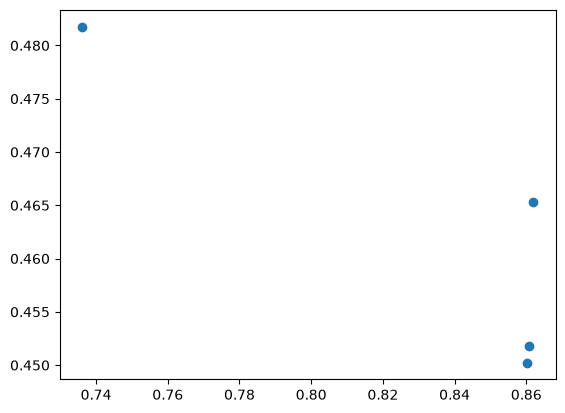

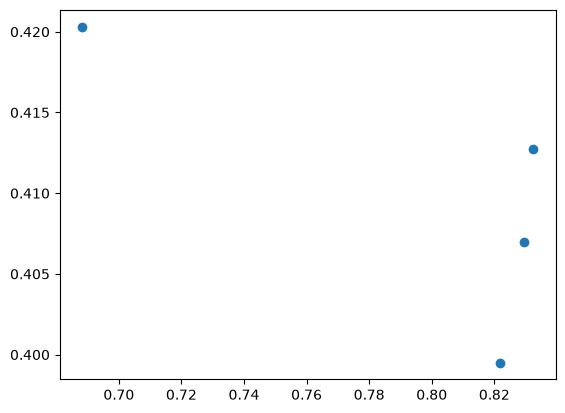

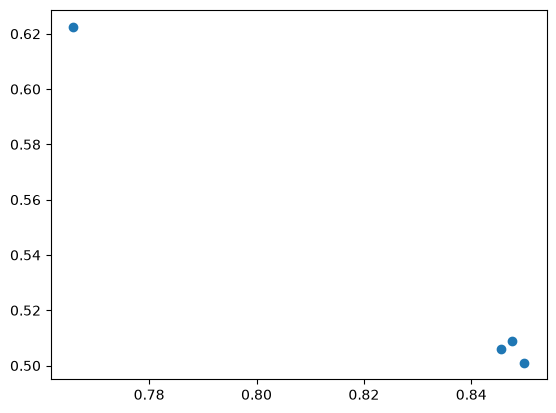

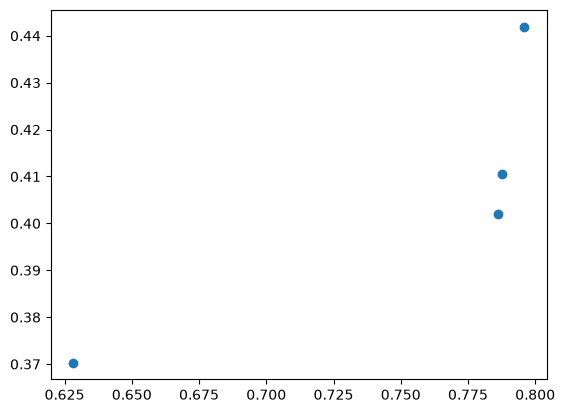

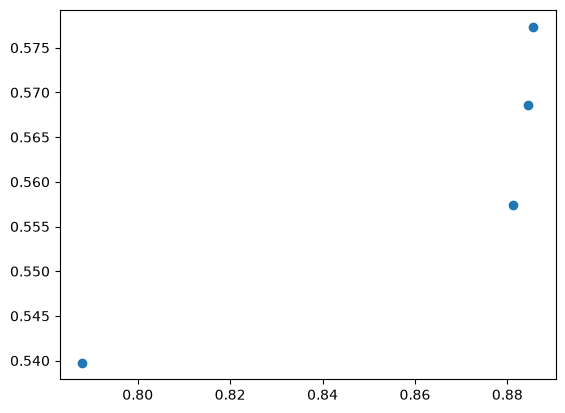

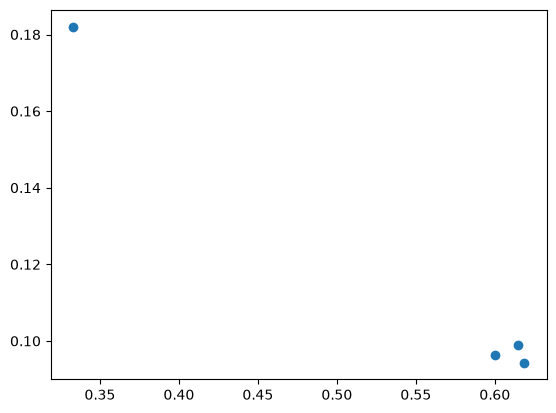

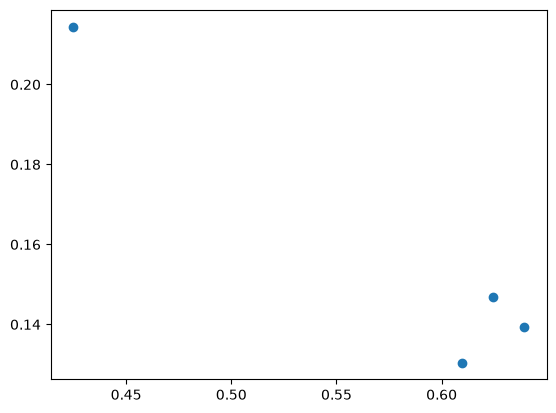

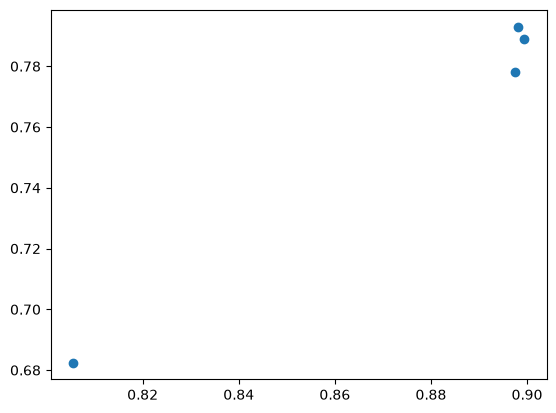

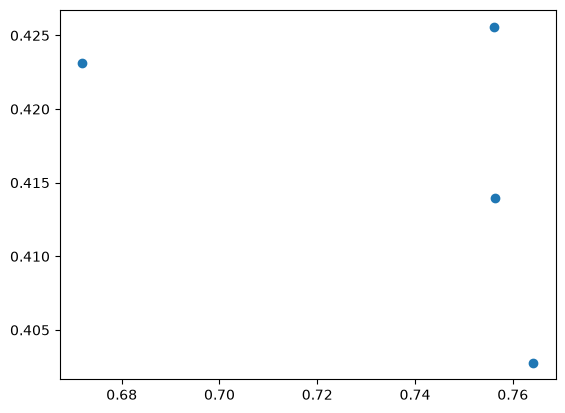

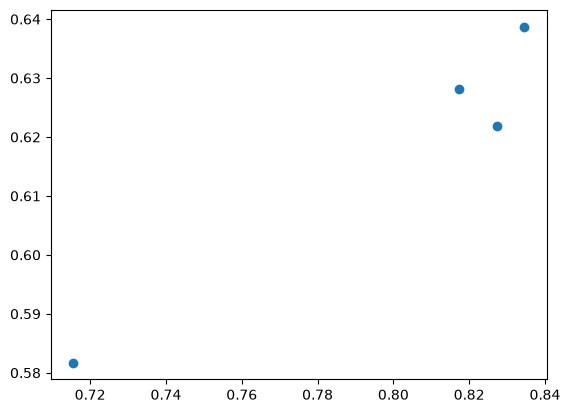

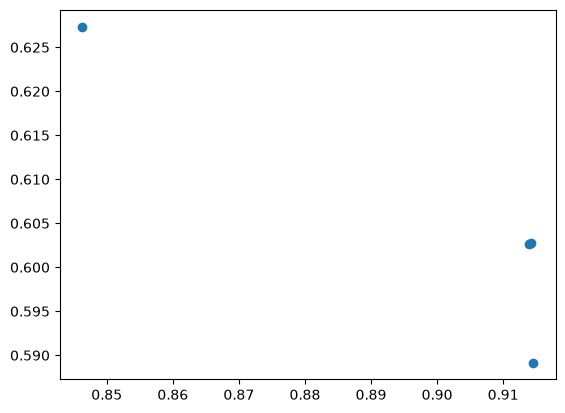

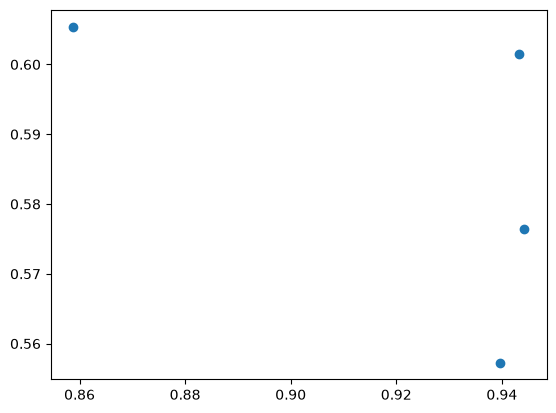

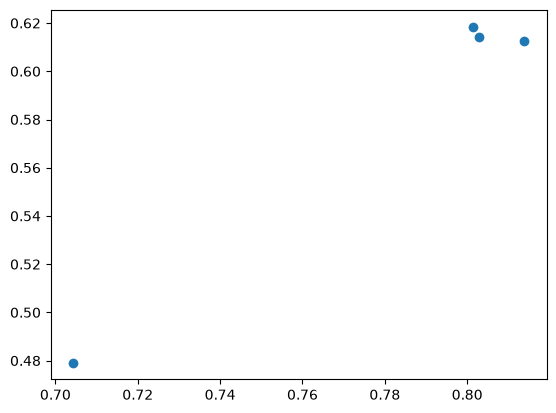

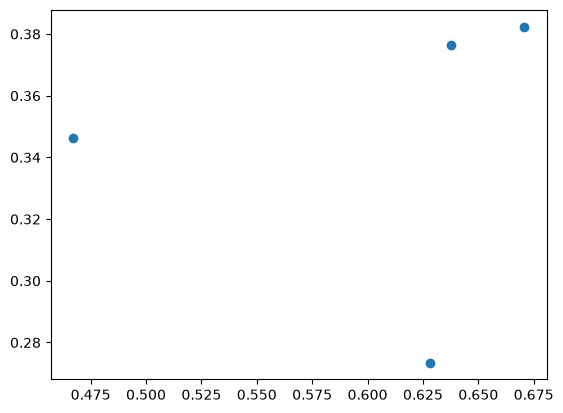

In [18]:
for cat in wide['category'].unique():
    slc = wide[(~wide['prauc_val'].isna()) & (~wide['prauc_lb'].isna()) & (wide['category'] == cat)]
    plt.figure()
    plt.scatter(slc['prauc_val'], slc['prauc_lb'])